100%|██████████| 434k/434k [00:00<00:00, 72.3MB/s]

Extracting files...
Loading data from: /root/.cache/kagglehub/datasets/johnp47/maven-churn-dataset/versions/1/telecom_customer_churn.csv

--- STEP 1: DATA CLEANING & ENCODING ---

--- STEP 2: TRAINING XGBOOST MODEL ---



--- STEP 3: PREDICTIVE PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.91      0.86      0.89       944
           1       0.69      0.79      0.74       374

    accuracy                           0.84      1318
   macro avg       0.80      0.83      0.81      1318
weighted avg       0.85      0.84      0.85      1318


--- STEP 4: GENERATING SHAP EXPLAINABILITY PLOTS ---
Calculating SHAP values (this takes a few seconds)...
Saved: shap_summary.png


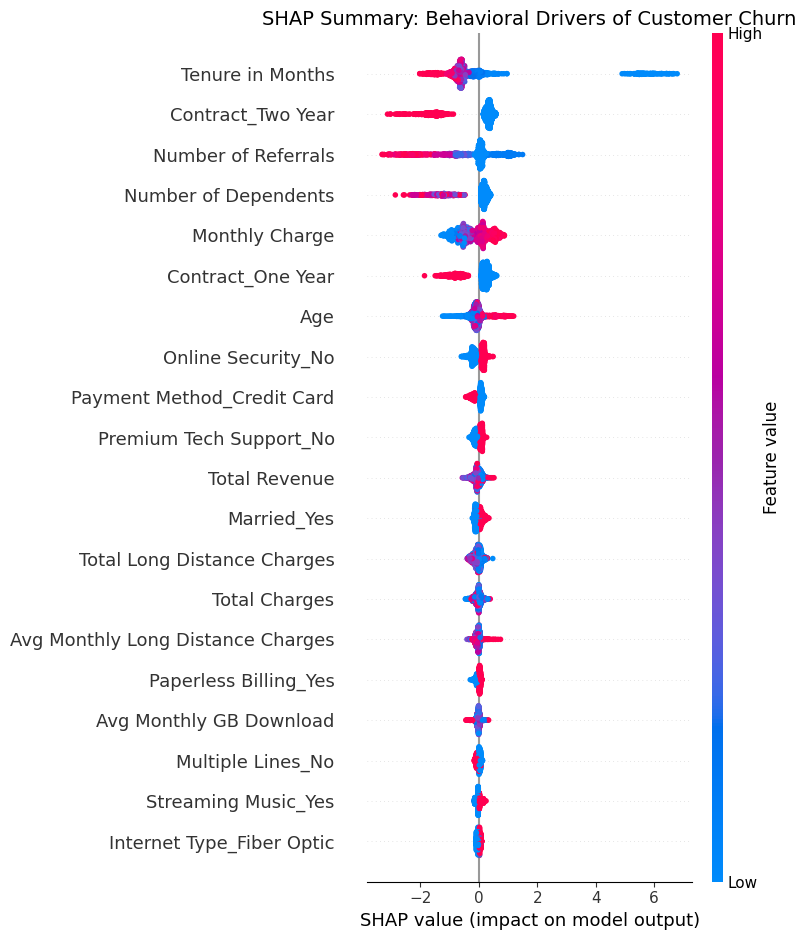

Saved: shap_dependence_tenure.png


<Figure size 800x600 with 0 Axes>

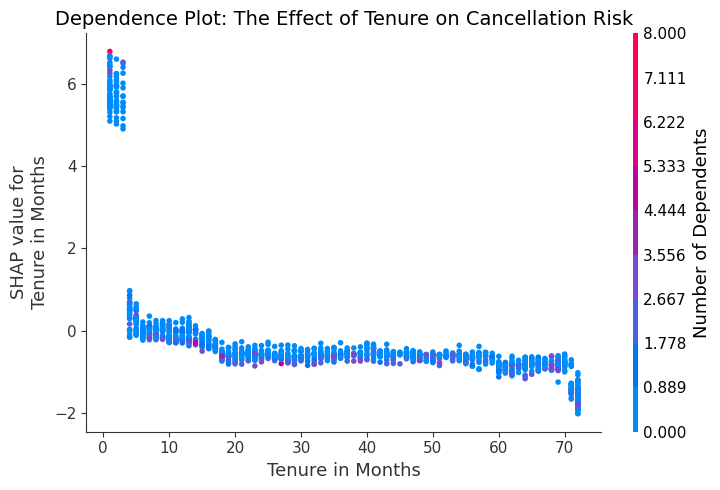

In [1]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ---------------------------------------------------------
# 1. DOWNLOAD & LOAD DATA
# ---------------------------------------------------------
print("Downloading dataset via Kagglehub...")
dataset_dir = kagglehub.dataset_download("johnp47/maven-churn-dataset")
file_path = os.path.join(dataset_dir, "telecom_customer_churn.csv")

print(f"Loading data from: {file_path}")
df = pd.read_csv(file_path, encoding="latin1")

# Filter out 'Joined' status to focus only on established behaviors
df = df[df['Customer Status'].isin(['Stayed', 'Churned'])].copy()
df['Churn_Target'] = df['Customer Status'].apply(lambda x: 1 if x == 'Churned' else 0)

# ---------------------------------------------------------
# 2. DATA CLEANING & PREPROCESSING
# ---------------------------------------------------------
print("\n--- STEP 1: DATA CLEANING & ENCODING ---")

# Drop Data Leakage and Non-Predictive Identifiers
columns_to_drop = [
    'Customer ID', 'Customer Status', 'Churn Category', 'Churn Reason',
    'City', 'Zip Code', 'Latitude', 'Longitude'
]
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
df = df.fillna(0)

# One-Hot Encode categorical variables
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# XGBoost requires all data to be strictly numerical (boolean to int)
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# ---------------------------------------------------------
# 3. MODEL TRAINING (XGBOOST)
# ---------------------------------------------------------
print("\n--- STEP 2: TRAINING XGBOOST MODEL ---")
X = df_encoded.drop('Churn_Target', axis=1)
y = df_encoded['Churn_Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Calculate scale_pos_weight to handle imbalanced churn data
ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]

# Initialize and train the state-of-the-art XGBoost Classifier
model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_train, y_train)

# ---------------------------------------------------------
# 4. PREDICTIVE EVALUATION
# ---------------------------------------------------------
print("\n--- STEP 3: PREDICTIVE PERFORMANCE ---")
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# ---------------------------------------------------------
# 5. EXPLAINABLE AI (SHAP) - The Research Core
# ---------------------------------------------------------
print("\n--- STEP 4: GENERATING SHAP EXPLAINABILITY PLOTS ---")
print("Calculating SHAP values (this takes a few seconds)...")

# Create a tree explainer for the XGBoost model
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# --- Picture 1: SHAP Summary Plot ---
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary: Behavioral Drivers of Customer Churn", fontsize=14)
plt.tight_layout()
# Save the first picture for the research paper
plt.savefig("shap_summary.png", dpi=300, bbox_inches='tight')
print("Saved: shap_summary.png")
plt.show()

# --- Picture 2: SHAP Dependence Plot for Tenure ---
# This proves the exact month where customer behavior shifts
plt.figure(figsize=(8, 6))
shap.dependence_plot("Tenure in Months", shap_values, X_test, show=False)
plt.title("Dependence Plot: The Effect of Tenure on Cancellation Risk", fontsize=14)
plt.tight_layout()
# Save the second picture for the research paper
plt.savefig("shap_dependence_tenure.png", dpi=300, bbox_inches='tight')
print("Saved: shap_dependence_tenure.png")
plt.show()